# SPRINT 1 · DATA EXPLORATION, RESEARCH QUESTIONS & GENERATIVE AI

## Objetivos

En este sprint vamos a:

1. Cargar y comprender el dataset.
2. Explorar sus características.
3. Visualizar relaciones y posibles patrones.
4. Estandarizar las variables.
5. Formular preguntas para aprendizaje no supervisado.
6. Reflexionar sobre reducción de dimensionalidad.
7. Utilizar IA generativa para revisar críticamente nuestro análisis.

---

## Enunciado

En este primer sprint trabajarás con el dataset **Iris** para familiarizarte con sus variables y realizar una primera exploración orientada al aprendizaje no supervisado.

El objetivo no es todavía construir un modelo de clustering, sino **comprender los datos antes de modelarlos**: revisar su estructura y calidad, analizar las distribuciones y relaciones entre variables, preparar las características numéricas y plantear preguntas que posteriormente puedan investigarse mediante técnicas de aprendizaje no supervisado.

El dataset contiene también la especie de cada observación (`target`). Sin embargo, dado que estamos trabajando desde una perspectiva de aprendizaje no supervisado, **no utilizaremos esta variable para construir los futuros grupos**. Podremos emplearla de manera exploratoria y, posteriormente, como referencia externa para interpretar o evaluar los patrones encontrados.

Al final del sprint utilizarás una herramienta de **IA generativa como asistente de análisis**. Su función será revisar tus primeras decisiones, sugerir alternativas y ayudarte a detectar aspectos que quizá hayas pasado por alto. Las propuestas de la IA deberán ser contrastadas con los datos: **la interpretación y las decisiones finales siguen siendo tuyas**.


# 0. Librerías


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

%matplotlib inline


# 1. Carga y comprensión de los datos

Cargamos el dataset Iris desde el repositorio UCI.


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

data = pd.read_csv(
    url,
    names=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width",
        "target"
    ]
)

data.sample(5)


,sepal_length,sepal_width,petal_length,petal_width,target
96,5.7,2.9,4.2,1.3,Iris-versicolor
75,6.6,3.0,4.4,1.4,Iris-versicolor
35,5.0,3.2,1.2,0.2,Iris-setosa
82,5.8,2.7,3.9,1.2,Iris-versicolor
107,7.3,2.9,6.3,1.8,Iris-virginica


## 1.1. Estructura del dataset

Ejecuto las siguientes comprobaciones.


In [ ]:
print("Dimensiones:", data.shape)

display(data.head())

data.info()


Dimensiones: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


Comprobacion de valores ausentes y obteneción de las principales estadísticas descriptivas.


In [ ]:
# Valores ausentes
print("Valores ausentes por variable:")
display(data.isna().sum())

# Filas duplicadas (mismas medidas y misma especie)
print("Filas duplicadas:", data.duplicated().sum())
display(data[data.duplicated(keep=False)])

# Estadísticos descriptivos
display(data.describe().round(2))

# Distribución de la etiqueta (solo a título informativo)
display(data["target"].value_counts())

Valores ausentes por variable:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

Filas duplicadas: 3


,sepal_length,sepal_width,petal_length,petal_width,target
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Tu interpretación

**¿Cuántas observaciones y variables contiene el dataset?**

> 150 observaciones y 5 columnas: 4 características numéricas (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) y la etiqueta `target`. Las tres especies están perfectamente balanceadas (50 observaciones cada una).

**¿Qué tipos de variables encontramos?**

> - Las 4 características son **numéricas continuas** (`float64`), medidas en centímetros con una precisión de 0,1 cm.
> - `target` es **categórica nominal** (`object`) con 3 niveles: *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*. No se usará como entrada para construir grupos.
> - Las escalas difieren claramente: `petal_length` va de 1,0 a 6,9 (desv. típica 1,76) mientras que `sepal_width` va de 2,0 a 4,4 (desv. típica 0,43), es decir, su dispersión es unas 4 veces menor.

**¿Has detectado algún problema de calidad que deba resolverse antes de continuar?**

> - **No hay valores ausentes** en ninguna columna.
> - Hay **3 filas duplicadas** exactas (una medida de *setosa* que aparece 3 veces y una de *virginica* que aparece 2 veces). Dado que las medidas tienen una resolución de 0,1 cm, es plausible que sean flores distintas con medidas coincidentes y no un error de carga, así que **las mantengo**, aunque lo tendré en cuenta: en clustering, los duplicados pesan doble en los centroides y aparecen con distancia 0 entre sí.
> - Los rangos (mín./máx.) son biológicamente razonables y no hay valores negativos ni imposibles. No veo ningún problema que obligue a limpiar datos; la única transformación necesaria es la **estandarización** por la diferencia de escalas.

# 2. Exploración de las características

Para trabajar posteriormente desde una perspectiva no supervisada, separamos las características (`X`) de la etiqueta conocida (`y`).


In [ ]:
X = data.drop(columns="target")
y = data["target"]

display(X.sample(5))


,sepal_length,sepal_width,petal_length,petal_width
136,6.3,3.4,5.6,2.4
148,6.2,3.4,5.4,2.3
69,5.6,2.5,3.9,1.1
135,7.7,3.0,6.1,2.3
33,5.5,4.2,1.4,0.2


> **IMPORTANTE:** `target` contiene información que conocemos porque Iris es un dataset didáctico etiquetado. En un problema no supervisado real podríamos no disponer de esta información.
>
> No utilizaremos `target` como entrada para construir los futuros grupos. Más adelante podrá servirnos como referencia externa para interpretar los resultados.


## 2.1. Distribuciones


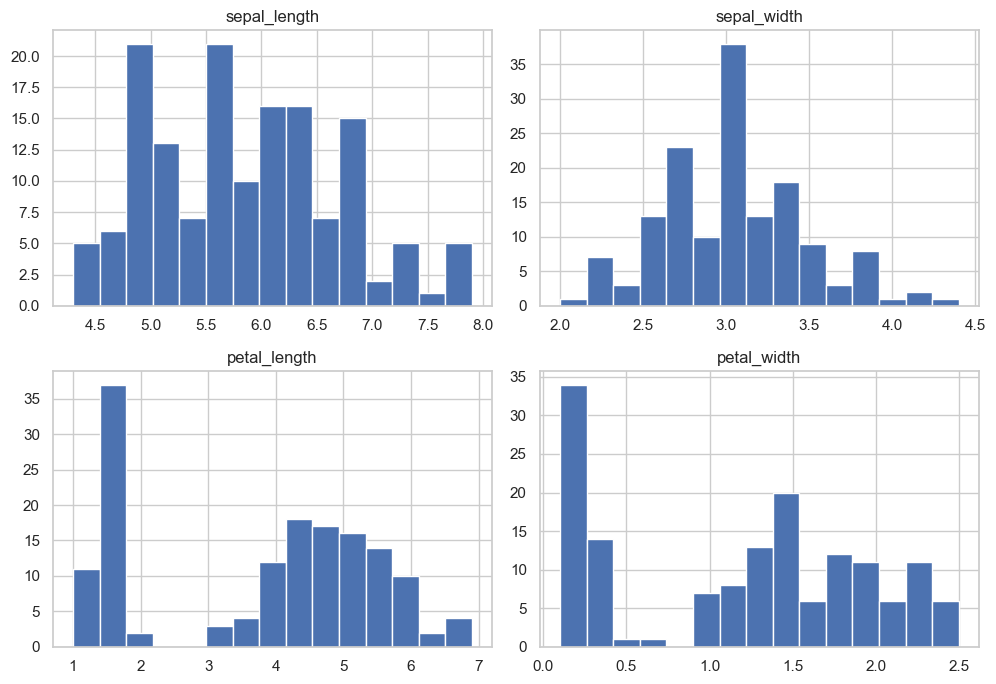

In [ ]:
X.hist(figsize=(10, 7), bins=15)
plt.tight_layout()
plt.show()


### Observa

- ¿Todas las variables presentan distribuciones similares?
- ¿Qué variables muestran mayor dispersión?
- ¿Observas indicios de diferentes grupos o estructuras?

> - **No.** Las variables del **sépalo** tienen distribuciones unimodales y aproximadamente simétricas (asimetría ≈ 0,3): `sepal_width` es la más parecida a una campana, centrada en torno a 3 cm. Las variables del **pétalo** son claramente **bimodales**: hay un bloque compacto de valores pequeños (`petal_length` < 2 cm, `petal_width` < 0,7 cm) separado por un **hueco vacío** del resto de observaciones.
> - La mayor dispersión la presenta `petal_length` (desv. típica 1,76 cm, rango 1,0–6,9), seguida de `sepal_length` (0,83) y `petal_width` (0,76). `sepal_width` es la menos dispersa (0,43).
> - Sí: el hueco en las variables del pétalo es un indicio claro de **al menos dos grupos naturales** (≈ 50 flores con pétalos muy pequeños frente a ≈ 100 con pétalos medianos/grandes). Dentro del bloque grande no se aprecia una separación tan nítida, lo que sugiere que podría haber subgrupos solapados.

## 2.2. Relaciones entre variables


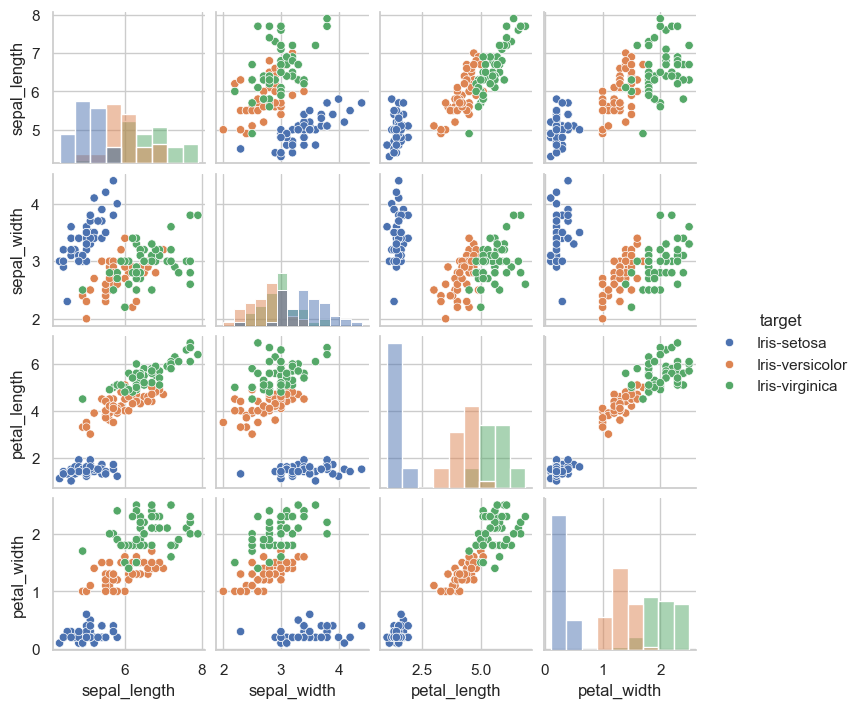

In [ ]:
sns.pairplot(
    data,
    hue="target",
    diag_kind="hist",
    height=1.8
)

plt.show()


Aunque mostramos la especie para ayudarnos a comprender este dataset, recuerda que **no utilizaremos esta etiqueta para generar los clusters**.

### Interpreta

**¿Qué parejas de variables parecen presentar relaciones más claras?**

> - `petal_length` – `petal_width`: relación lineal positiva muy fuerte, los puntos forman casi una línea recta. Es el patrón más destacado del dataset.
> - `sepal_length` – `petal_length` y `sepal_length` – `petal_width`: también relación positiva clara (flores más grandes tienen pétalos más grandes), aunque con más dispersión.
> - `sepal_width` apenas se relaciona linealmente con las demás. Curiosamente, *dentro* de cada especie sí parece haber relación positiva con `sepal_length`, pero en el conjunto global se diluye porque el grupo de pétalos pequeños tiene sépalos anchos y cortos (un caso de paradoja de Simpson).

**¿Qué características parecen diferenciar mejor unas observaciones de otras?**

> `petal_length` y `petal_width`. En cualquier gráfico donde aparezca alguna de las dos, el grupo de pétalos pequeños (*setosa*) queda completamente aislado: el pétalo más largo de setosa mide 1,9 cm y el más corto de las otras dos especies 3,0 cm. Además, ordenan razonablemente bien a las otras dos especies (versicolor con valores intermedios, virginica con los mayores). Como variable individual, `petal_length` es la que mejor separa.

**¿Dónde observas mayor solapamiento?**

> - Entre *versicolor* y *virginica*, que forman una nube continua sin hueco claro. En `petal_length` se solapan aproximadamente entre 4,5 y 5,1 cm y en `petal_width` entre 1,4 y 1,8 cm.
> - En las variables del sépalo el solapamiento es mucho mayor: en `sepal_width` las tres especies comparten rango (setosa 2,3–4,4; versicolor 2,0–3,4; virginica 2,2–3,8) y en `sepal_length` versicolor y virginica se mezclan casi por completo.
> - Implicación: sin la etiqueta, un algoritmo encontrará con facilidad **2 grupos**; separar un tercero dentro de la nube grande será mucho más difícil y probablemente con fronteras ambiguas.

## 2.3. Correlaciones

Completo el código para calcular la matriz de correlaciones entre las variables numéricas.


In [ ]:
correlation_matrix = X.corr(method="pearson").round(2)

correlation_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.11,0.87,0.82
sepal_width,-0.11,1.00,-0.42,-0.36
petal_length,0.87,-0.42,1.00,0.96
petal_width,0.82,-0.36,0.96,1.00


Represento ahora gráficamente la información obtenida.


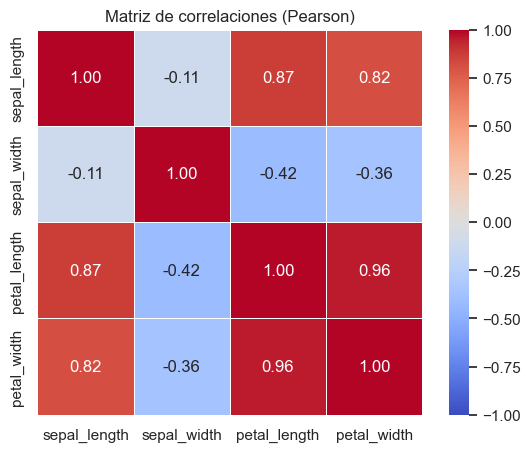

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlaciones (Pearson)")

plt.show()

### Interpreta

**¿Existen variables fuertemente relacionadas? ¿Qué implicaciones podría tener esto para un análisis posterior?**

> Sí:
> - `petal_length` – `petal_width`: **r = 0,96** (casi redundantes).
> - `sepal_length` – `petal_length`: **r = 0,87**.
> - `sepal_length` – `petal_width`: **r = 0,82**.
> - `sepal_width` tiene correlaciones débiles y negativas con el resto (−0,11 a −0,42).
>
> Implicaciones:
> 1. **Información redundante**: tres de las cuatro variables miden en gran parte lo mismo (el "tamaño" de la flor). En un algoritmo basado en distancia euclídea, esa dimensión del tamaño cuenta prácticamente tres veces, mientras que `sepal_width` aporta casi en solitario la otra dirección de variación.
> 2. **Potencial de reducción de dimensionalidad**: una correlación tan alta indica que los datos viven aproximadamente en un subespacio de menor dimensión; una técnica como PCA debería resumir gran parte de la varianza en 1–2 componentes.
> 3. **Cuidado al interpretar**: la correlación global está muy influida por la separación entre grupos (setosa en un extremo, virginica en el otro), así que no implica necesariamente la misma relación dentro de cada grupo.

# 3. Feature Scaling · Estandarización

Muchos algoritmos de aprendizaje no supervisado utilizan **distancias** entre observaciones.

Si una variable presenta una escala o dispersión mucho mayor que otra, puede influir de forma desproporcionada en esas distancias.

En este sprint utilizaremos `StandardScaler`.

> **Nota terminológica:** `StandardScaler` realiza una **estandarización**, no una normalización Min-Max.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns
)

X_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


Comprueba el resultado.


In [ ]:
X_scaled.describe().round(2)


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.44,-1.57,-1.44
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.12,0.34,0.13
75%,0.67,0.57,0.76,0.79
max,2.49,3.11,1.79,1.71


### Reflexiona

**¿Qué ha cambiado respecto a los datos originales?**

> - Cada variable tiene ahora **media 0** y **desviación típica 1** (`describe()` muestra 1,00 porque usa la desviación típica muestral; `StandardScaler` usa la poblacional, de ahí la mínima diferencia en decimales).
> - Las unidades ya no son centímetros sino "número de desviaciones típicas respecto a la media". Por ejemplo, `petal_length` pasa de un rango 1,0–6,9 a aproximadamente −1,57–1,79.
> - **No cambia la forma de las distribuciones** ni las relaciones entre variables: es una transformación lineal, por lo que las correlaciones, la bimodalidad del pétalo y el orden de las observaciones se mantienen. Solo cambian centro y escala.

**¿Por qué puede ser especialmente importante este paso antes de aplicar algoritmos basados en distancias, como K-means?**

> K-means (y también clustering jerárquico, DBSCAN o k-NN) asigna observaciones según la **distancia euclídea**, que suma diferencias al cuadrado de cada variable. Sin estandarizar, una variable con más dispersión domina la distancia: la varianza de `petal_length` (≈ 3,1 cm²) es unas **16 veces** la de `sepal_width` (≈ 0,19 cm²), de modo que `sepal_width` apenas influiría en los grupos aunque aporte información distinta del resto. Al estandarizar, todas las variables contribuyen en igualdad de condiciones y los resultados no dependen de las unidades de medida.
>
> Lo mismo ocurre en **PCA**: busca direcciones de máxima varianza, por lo que sin estandarizar la primera componente estaría dominada casi por completo por `petal_length` por el simple hecho de tener mayor escala.
>
> Matiz: aquí todas las variables están en cm, así que la diferencia de escala tiene cierto significado biológico. Estandarizar es una **decisión**, no una obligación; la tomo porque no tengo motivos para considerar que la variable con más dispersión deba pesar más en la similitud entre flores.

# 4. Preguntas de investigación

Antes de seleccionar algoritmos, formula **tres preguntas que quieras investigar a partir de los datos**.

Evita preguntas cuya respuesta dependa simplemente de consultar `target`.

No es necesario conocer todavía el algoritmo exacto que utilizarías. Las preguntas deben centrarse en descubrir estructuras presentes en los datos, por ejemplo:

- existencia de grupos naturales;
- observaciones similares;
- variables relacionadas;
- posibles subgrupos;
- estructuras que puedan representarse con menos dimensiones.


## Pregunta 1

**Pregunta:**

> ¿Existen grupos naturales de flores a partir únicamente de sus cuatro medidas y, en tal caso, cuántos grupos están respaldados por los datos: 2 o 3?

**¿Qué patrón intentarías descubrir?**

> Los histogramas y el pairplot muestran un grupo muy separado (pétalos pequeños) y una nube grande en la que podría haber dos subgrupos solapados. Quiero averiguar si la estructura natural de los datos es de 2 grupos bien definidos o si un tercer grupo dentro de la nube grande tiene entidad suficiente para considerarse un grupo propio.

**¿Qué evidencia necesitarías para responderla?**

> - Comparar varios valores de *k* con métricas internas (método del codo con la inercia, **coeficiente de silueta**, índice de Davies-Bouldin) sin usar `target`.
> - Un dendrograma de clustering jerárquico para ver a qué altura se fusionan los grupos: si dos de ellos se unen mucho antes que el tercero, indica que son subgrupos de un mismo bloque.
> - Estabilidad de los grupos al cambiar la semilla o al remuestrear los datos.
> - Solo al final, usar `target` como referencia externa (tabla de contingencia, ARI) para interpretar los grupos encontrados.

## Pregunta 2

**Pregunta:**

> ¿Qué observaciones se encuentran en la frontera entre grupos o lejos de cualquier grupo, y qué tienen en común sus medidas?

**¿Qué patrón intentarías descubrir?**

> En la zona de `petal_length` ≈ 4,5–5,1 cm y `petal_width` ≈ 1,4–1,8 cm la nube grande no tiene un corte claro. Quiero identificar qué flores tienen una pertenencia ambigua (están casi a la misma distancia de dos centroides) y si existen flores atípicas que no encajan bien en ningún grupo, en lugar de forzar a cada observación a pertenecer a uno.

**¿Qué evidencia necesitarías para responderla?**

> - Valores de silueta por observación: valores cercanos a 0 o negativos señalan puntos fronterizos o mal asignados.
> - Distancia de cada punto a su centroide y al segundo centroide más cercano.
> - Un método basado en densidad (DBSCAN) o un modelo de mezclas gaussianas, que permiten marcar ruido o asignar probabilidades de pertenencia.
> - Visualizar esas observaciones en el pairplot o en una proyección 2D para comprobar si se concentran en la zona de solapamiento identificada en el EDA.

## Pregunta 3

**Pregunta:**

> ¿Puede representarse la variabilidad de las cuatro medidas en solo dos dimensiones sin perder la estructura de grupos, y qué combinación de variables define cada una de esas dimensiones?

**¿Qué patrón intentarías descubrir?**

> Tres variables están muy correlacionadas (r de 0,82 a 0,96) y `sepal_width` va bastante por libre. Espero encontrar una dimensión dominante de **"tamaño general"** (sobre todo del pétalo) y una segunda dimensión ligada a la **anchura del sépalo**, y comprobar si los grupos siguen viéndose separados en ese plano.

**¿Qué evidencia necesitarías para responderla?**

> - Proporción de varianza explicada (y acumulada) por cada componente de PCA sobre los datos estandarizados.
> - Las cargas (*loadings*) de cada variable en las componentes para darles una interpretación.
> - Una proyección 2D de las observaciones (inicialmente sin colorear por `target`) para ver si se mantienen los grupos y el hueco observado en el pétalo.
> - Comparar los clusters obtenidos en el espacio original y en el espacio reducido: si coinciden, la reducción conserva la estructura relevante.

# 5. Reducción de dimensionalidad: primera decisión analítica

Todavía no vamos a aplicar PCA, t-SNE o UMAP. Antes queremos razonar **por qué podríamos necesitarlos**.


## 5.1. PCA

PCA busca nuevas dimensiones que capturen la mayor cantidad posible de variabilidad mediante combinaciones lineales de las variables originales.

A partir de tu EDA:

**¿Qué podría aportar PCA a este dataset? Identifica al menos dos argumentos.**

> 1. **Eliminar redundancia por correlación lineal fuerte.** `petal_length`, `petal_width` y `sepal_length` tienen correlaciones de 0,82–0,96, y en el pairplot sus relaciones son claramente **lineales** (nubes alargadas en línea recta). Ese es exactamente el tipo de estructura que PCA capta bien: es esperable que una sola componente (un eje de "tamaño", combinación de estas tres variables) explique la mayor parte de la varianza.
> 2. **Visualización en 2D de un problema 4D.** El pairplot obliga a mirar 6 diagramas de pares por separado; con PCA podemos ver todas las observaciones en un único plano. Como `sepal_width` es casi independiente de las otras, previsiblemente aportará la segunda componente, de modo que 2 componentes podrían conservar casi toda la información.
> 3. **Mejor punto de partida para el clustering.** Al decorrelacionar las variables, se evita que el "tamaño" cuente tres veces en la distancia euclídea, y descartar las últimas componentes (de muy poca varianza) puede eliminar parte del ruido de medida.
> 4. **Interpretabilidad.** Al ser combinaciones lineales, las cargas permiten explicar qué significa cada eje en términos de las variables originales, algo que no ofrecen t-SNE ni UMAP.
>
> Limitación a tener en cuenta: PCA maximiza varianza, no separación entre grupos; nada garantiza que la dirección que mejor separe versicolor de virginica sea una de las primeras componentes.

## 5.2. Técnicas no lineales

Técnicas como t-SNE o UMAP permiten representar estructuras que no necesariamente pueden describirse mediante combinaciones lineales.

**¿Qué indicios te llevarían a probar posteriormente una técnica no lineal?**

> - Que la proyección PCA en 2D **siga mostrando solapamiento** entre los grupos de la nube grande a pesar de explicar mucha varianza: la separación podría depender de relaciones locales que una proyección lineal global no conserva.
> - Que se observen **relaciones curvas** o grupos con formas no elípticas (alargados, en anillo, encadenados) en los diagramas de pares o en el plano PCA.
> - Que la varianza explicada se reparta entre muchas componentes (necesitar 3–4 componentes para retener la mayor parte), lo que indicaría que la estructura no es aproximadamente lineal ni de baja dimensión.
> - Que el interés sea explorar **vecindarios locales** (qué flores son más parecidas entre sí, Pregunta 2) más que la varianza global.
>
> En el EDA de Iris estos indicios son **débiles**: las relaciones son mayoritariamente lineales y el grupo separado lo es de forma evidente. Aun así, el solapamiento versicolor/virginica justifica probar t-SNE o UMAP como **contraste**, no como sustituto de PCA.

**¿Puedes afirmar únicamente con el EDA que una técnica no lineal será mejor que PCA? ¿Por qué?**

> **No.** El EDA solo muestra proyecciones de 2 variables a la vez; no permite ver relaciones conjuntas de las 4 dimensiones ni comprobar cuánta varianza captaría PCA. Para comparar habría que aplicar ambas y evaluarlas con criterios concretos (varianza explicada, conservación de vecinos, calidad de los clusters resultantes).
>
> Además, "mejor" depende del objetivo: t-SNE y UMAP suelen dar separaciones visualmente más nítidas, pero **distorsionan distancias globales y tamaños de los grupos**, dependen de hiperparámetros (perplejidad, `n_neighbors`) y de la semilla, y sus ejes no son interpretables. Con solo 150 observaciones y 4 variables con relaciones mayoritariamente lineales, la evidencia del EDA apunta más bien a que PCA será suficiente para resumir los datos, y lo que habría que comprobar es si una técnica no lineal **añade** algo.

# 6. IA generativa como asistente de análisis

Ahora sí.

Primero has explorado los datos, formulado tus preguntas y realizado una primera reflexión analítica.

Utilizaremos una IA generativa para obtener una **segunda opinión**, no para sustituir el análisis anterior.

Puedes utilizar ChatGPT, Claude, Gemini, Copilot u otra herramienta similar.

> **Privacidad:** no introduzcas información personal, confidencial o sensible en una herramienta externa. En este caso trabajamos con Iris, un dataset público, por lo que no existe ese problema.


## 6.1. Prepara el contexto

Resume la información que vas a proporcionar a la IA.

**Dataset y variables:**

> Dataset Iris (UCI): 150 flores, 4 características numéricas continuas medidas en cm (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) y una etiqueta de especie (`target`, 3 clases balanceadas) que no se usará para construir los grupos. Al ser un dataset público, no hay problemas de privacidad al compartirlo con una herramienta externa.

**Principales hallazgos de tu EDA:**

> 1. Calidad: 150 observaciones, 4 variables numéricas continuas en cm (precisión 0,1), sin valores ausentes. Hay 3 filas duplicadas exactas que he decidido mantener. La etiqueta de especie está balanceada (50/50/50) y no se usará para construir los grupos.
> 2. Escalas distintas: la desviación típica va de 0,43 (sepal_width) a 1,76 (petal_length), así que he estandarizado con StandardScaler.
> 3. Las variables del pétalo son bimodales, con un hueco que aísla un grupo de unas 50 flores con pétalos pequeños (petal_length < 2 cm). Las del sépalo son unimodales y aproximadamente simétricas.
> 4. Correlaciones fuertes y lineales: petal_length-petal_width r = 0,96; sepal_length-petal_length r = 0,87; sepal_length-petal_width r = 0,82. sepal_width está poco correlacionada con el resto (-0,11 a -0,42).
> 5. La nube de las ≈100 flores restantes es continua: hay solapamiento en petal_length ≈ 4,5-5,1 cm y petal_width ≈ 1,4-1,8 cm, y en las variables del sépalo el solapamiento es aún mayor.

**Tus tres preguntas de investigación:**

> P1. ¿Existen grupos naturales a partir solo de las cuatro medidas y cuántos están respaldados por los datos: 2 o 3? (evidencia: codo, silueta, Davies-Bouldin, dendrograma, estabilidad).
> P2. ¿Qué observaciones están en la frontera entre grupos o lejos de cualquiera de ellos, y qué tienen en común? (evidencia: silueta por punto, distancias a centroides, DBSCAN o mezclas gaussianas).
> P3. ¿Puede representarse la variabilidad en 2 dimensiones sin perder la estructura de grupos y qué combinación de variables define cada dimensión? (evidencia: varianza explicada y cargas de PCA, proyección 2D).

## 6.2. Consulta a la IA

Puedes utilizar el siguiente prompt como punto de partida y adaptarlo si lo consideras necesario.


In [ ]:
prompt = '''
Actúa como revisor crítico de un análisis exploratorio orientado
a aprendizaje no supervisado.

Estoy trabajando con el dataset Iris, formado por 150 observaciones
y cuatro características numéricas: longitud y anchura del sépalo
y longitud y anchura del pétalo.

Mis principales observaciones durante el EDA son:

1. Calidad: 150 observaciones, 4 variables numéricas continuas en cm (precisión 0,1), sin valores ausentes. Hay 3 filas duplicadas exactas que he decidido mantener. La etiqueta de especie está balanceada (50/50/50) y no se usará para construir los grupos.
2. Escalas distintas: la desviación típica va de 0,43 (sepal_width) a 1,76 (petal_length), así que he estandarizado con StandardScaler.
3. Las variables del pétalo son bimodales, con un hueco que aísla un grupo de unas 50 flores con pétalos pequeños (petal_length < 2 cm). Las del sépalo son unimodales y aproximadamente simétricas.
4. Correlaciones fuertes y lineales: petal_length-petal_width r = 0,96; sepal_length-petal_length r = 0,87; sepal_length-petal_width r = 0,82. sepal_width está poco correlacionada con el resto (-0,11 a -0,42).
5. La nube de las ≈100 flores restantes es continua: hay solapamiento en petal_length ≈ 4,5-5,1 cm y petal_width ≈ 1,4-1,8 cm, y en las variables del sépalo el solapamiento es aún mayor.

He formulado estas preguntas de investigación:

P1. ¿Existen grupos naturales a partir solo de las cuatro medidas y cuántos están respaldados por los datos: 2 o 3? (evidencia: codo, silueta, Davies-Bouldin, dendrograma, estabilidad).
P2. ¿Qué observaciones están en la frontera entre grupos o lejos de cualquiera de ellos, y qué tienen en común? (evidencia: silueta por punto, distancias a centroides, DBSCAN o mezclas gaussianas).
P3. ¿Puede representarse la variabilidad en 2 dimensiones sin perder la estructura de grupos y qué combinación de variables define cada dimensión? (evidencia: varianza explicada y cargas de PCA, proyección 2D).

1. Evalúa si las preguntas son adecuadas para aprendizaje no supervisado
   y señala cómo podría mejorarlas.

2. Identifica algún patrón, problema de calidad o aspecto de
   preprocesamiento que debería comprobar antes de modelar.

3. Propón dos análisis o visualizaciones adicionales que puedan ayudarme
   a contrastar mis hipótesis.

4. Indica si tendría sentido explorar PCA y/o alguna técnica no lineal
   de reducción de dimensionalidad y explica por qué.

5. No inventes resultados. Diferencia claramente entre conclusiones
   respaldadas por la información proporcionada e hipótesis que debo
   verificar mediante código.

Presenta la respuesta de forma clara y justifica brevemente cada propuesta.
'''

print(prompt)


Actúa como revisor crítico de un análisis exploratorio orientado
a aprendizaje no supervisado.

Estoy trabajando con el dataset Iris, formado por 150 observaciones
y cuatro características numéricas: longitud y anchura del sépalo
y longitud y anchura del pétalo.

Mis principales observaciones durante el EDA son:

1. Calidad: 150 observaciones, 4 variables numéricas continuas en cm (precisión 0,1), sin valores ausentes. Hay 3 filas duplicadas exactas que he decidido mantener. La etiqueta de especie está balanceada (50/50/50) y no se usará para construir los grupos.
2. Escalas distintas: la desviación típica va de 0,43 (sepal_width) a 1,76 (petal_length), así que he estandarizado con StandardScaler.
3. Las variables del pétalo son bimodales, con un hueco que aísla un grupo de unas 50 flores con pétalos pequeños (petal_length < 2 cm). Las del sépalo son unimodales y aproximadamente simétricas.
4. Correlaciones fuertes y lineales: petal_length-petal_width r = 0,96; sepal_length-petal_leng

> Esta celda **no conecta automáticamente con ningún modelo de IA**. Su finalidad es ayudarte a construir y copiar un prompt bien contextualizado en la herramienta que utilices.


## 6.3. Documenta la interacción

**Prompt finalmente utilizado:**

> El generado en la celda anterior (plantilla del enunciado completada con los 5 hallazgos y las 3 preguntas de las secciones 1–4). Herramienta utilizada: **Claude** (Anthropic).

**Resume las principales recomendaciones obtenidas:**

> 1. **Preguntas:** las tres son adecuadas porque buscan estructura sin usar la etiqueta. Sugiere concretarlas más: en P1, fijar de antemano qué métricas y qué rango de *k* se compararán, y advertir que con un grupo tan separado la silueta tiende a favorecer *k* = 2 aunque existan 3 especies, por lo que "cuántos grupos hay" y "cuántas especies hay" no son la misma pregunta. En P2, definir un criterio operativo de "frontera" (por ejemplo, silueta < 0,25). En P3, fijar un umbral de varianza retenida (p. ej. ≥ 90 %).
> 2. **Calidad y preprocesamiento:**
>    - Revisar los **duplicados** y su efecto (pesan doble en los centroides).
>    - Comprobar **valores atípicos** con boxplots, en especial en `sepal_width`, y valorar si eliminarlos o usar un escalado robusto (`RobustScaler`).
>    - Valorar **eliminar `petal_width`** por su correlación de 0,96 con `petal_length`, para no duplicar el peso del tamaño del pétalo en la distancia.
>    - Recordar que la versión UCI tiene erratas documentadas en algunas filas respecto a los datos originales de Fisher (*hipótesis a comprobar*, no afecta al análisis exploratorio).
> 3. **Análisis adicionales:** (a) boxplots o violinplots por variable para cuantificar atípicos y bimodalidad; (b) una proyección PCA 2D **sin colorear** por especie, junto con la varianza explicada acumulada, para ver qué estructura es visible sin conocer la etiqueta.
> 4. **Reducción de dimensionalidad:** PCA tiene sentido como primera opción (relaciones lineales y correlaciones altas, conclusión respaldada por los datos aportados); t-SNE/UMAP solo como contraste visual del solapamiento, con advertencias sobre la distorsión de distancias globales y su dependencia de hiperparámetros. Señala como **hipótesis por verificar** que 2 componentes retengan la mayor parte de la varianza.

## 6.4. Tú decides

Esta es la parte más importante del uso de IA.

No se valorará positivamente aceptar todas las respuestas. Detectar limitaciones, errores, recomendaciones genéricas o afirmaciones sin evidencia también demuestra competencia analítica.


### Una recomendación que acepto

**Recomendación:**

> Revisar los duplicados y mirar la estructura de los datos en una proyección PCA 2D **sin colorear por especie**, comprobando la varianza explicada acumulada antes de decidir el número de dimensiones.

**La acepto porque:**

> - Es coherente con la perspectiva no supervisada: el pairplot coloreado por `target` me ha hecho "ver" tres grupos que quizá los datos por sí solos no muestran. Una proyección sin color es una forma honesta de comprobar qué estructura es descubrible sin la etiqueta.
> - Responde directamente a mi Pregunta 3 y es verificable con un análisis muy sencillo.
> - Los duplicados afectan a algoritmos de distancia (distancia 0, doble peso), así que conviene saber exactamente cuántos hay y de qué zona del espacio son.

**¿Cómo la he verificado o cómo podría verificarla con los datos?**

> En la celda de comprobación opcional:
> - Confirmo que hay **3 duplicados** (una medida de setosa ×3 y una de virginica ×2). Afectan a 5 de 150 filas y las medidas tienen resolución de 0,1 cm, así que los mantengo como observaciones reales; no cambian la estructura global.
> - Calculo PCA sobre `X_scaled`: **PC1 explica ≈ 73 % y PC2 ≈ 23 % (≈ 96 % acumulado)**. PC1 carga casi por igual en `petal_length`, `petal_width` y `sepal_length` (eje de "tamaño") y PC2 está dominada por `sepal_width`, tal como anticipaba el EDA.
> - En la proyección sin colorear se distinguen claramente **dos** nubes, no tres: esto refuerza la cautela de mi Pregunta 1.

### Una recomendación que cuestiono, modifico o descarto

**Recomendación:**

> (a) Eliminar valores atípicos de `sepal_width` o usar `RobustScaler`, y (b) eliminar `petal_width` por estar muy correlacionada con `petal_length`.

**No la acepto directamente porque:**

> - **(a) Descarto** eliminar atípicos. Los boxplots marcan solo **4 puntos** fuera de los bigotes en `sepal_width` (y ninguno en las demás variables) y sus valores (2,0 cm por abajo y 4,1–4,4 cm por arriba) son medidas biológicamente plausibles, no errores. En un dataset de 150 filas, eliminarlos pierde información, y en clustering precisamente esos puntos pueden ser los interesantes (Pregunta 2). Como la asimetría de todas las variables es baja (|skew| ≤ 0,33) y no hay colas extremas, `StandardScaler` es adecuado y no hace falta un escalado robusto.
> - **(b) Modifico** la sugerencia de eliminar `petal_width`. Es cierto que la redundancia existe (r = 0,96), pero eliminar variables a mano antes de modelar es una decisión prematura: `petal_width` también ayuda a separar la zona de solapamiento. En lugar de eliminarla, prefiero tratar la redundancia de forma sistemática con **PCA**, que combina las variables correlacionadas en una componente sin descartar ninguna, y comparar más adelante el clustering con las 4 variables frente al realizado sobre las componentes principales.

**Evidencia o razonamiento utilizado:**

> - Recuento IQR de atípicos y boxplots en la celda de comprobación: 4 atípicos en `sepal_width`, 0 en el resto.
> - Asimetría calculada: entre −0,27 y 0,33 en todas las variables.
> - Matriz de correlaciones (sección 2.3) y cargas de PCA: PC1 ya agrupa `petal_length`, `petal_width` y `sepal_length` con cargas casi iguales, lo que resuelve la redundancia sin perder variables.

### Comprobación opcional

Si una de las recomendaciones de la IA puede comprobarse mediante una visualización o un pequeño análisis adicional, utiliza esta celda.

No es obligatorio aceptar ni implementar todas sus sugerencias.

Verificamos: (1) duplicados, (2) atípicos y asimetría (recomendación descartada), y (3) varianza explicada y proyección PCA 2D sin colorear (recomendación aceptada).

> **Nota:** PCA se aplica aquí únicamente como comprobación de las recomendaciones de la IA y de la Pregunta 3; el análisis completo de reducción de dimensionalidad se hará en sprints posteriores.

Filas duplicadas (solo características): 3


,atipicos_IQR,asimetria
sepal_length,0,0.31
sepal_width,4,0.33
petal_length,0,-0.27
petal_width,0,-0.10


Valores atípicos de sepal_width: [2.0, 4.1, 4.2, 4.4]


,varianza_explicada,acumulada
PC1,0.728,0.728
PC2,0.230,0.958
PC3,0.037,0.995
PC4,0.005,1.000


,PC1,PC2,PC3,PC4
sepal_length,0.52,0.37,0.72,-0.26
sepal_width,-0.26,0.93,-0.24,0.12
petal_length,0.58,0.02,-0.14,0.80
petal_width,0.57,0.07,-0.63,-0.52


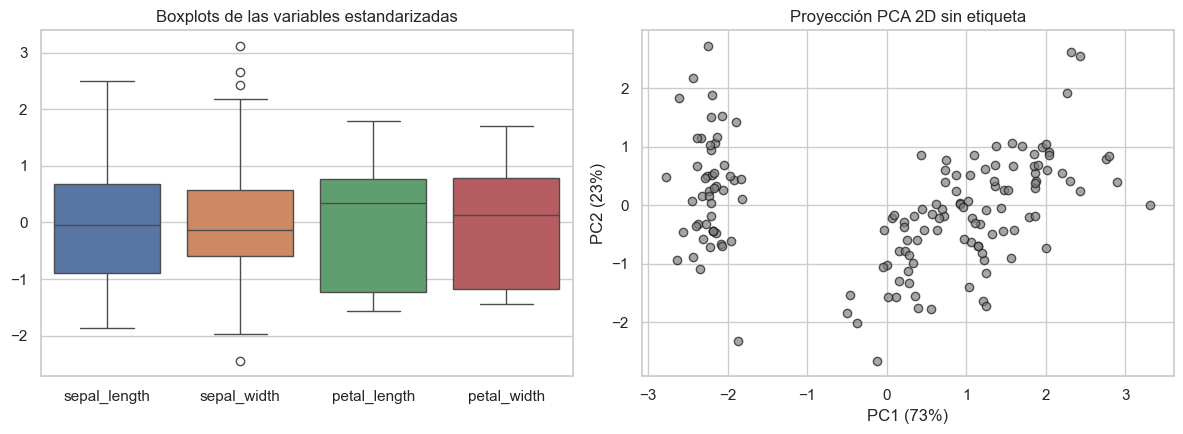

In [ ]:
from sklearn.decomposition import PCA

# 1) Duplicados
print("Filas duplicadas (solo características):", X.duplicated().sum())

# 2) Atípicos (criterio IQR) y asimetría
q1, q3 = X.quantile(0.25), X.quantile(0.75)
iqr = q3 - q1
outliers = ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum()
display(pd.DataFrame({"atipicos_IQR": outliers, "asimetria": X.skew().round(2)}))
print("Valores atípicos de sepal_width:",
      sorted(X.loc[(X.sepal_width < q1.sepal_width - 1.5 * iqr.sepal_width) |
                   (X.sepal_width > q3.sepal_width + 1.5 * iqr.sepal_width), "sepal_width"]))

# 3) PCA sobre los datos estandarizados
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "varianza_explicada": pca.explained_variance_ratio_.round(3),
    "acumulada": pca.explained_variance_ratio_.cumsum().round(3)
}, index=[f"PC{i + 1}" for i in range(X.shape[1])])
display(explained)

loadings = pd.DataFrame(pca.components_.T, index=X.columns,
                        columns=explained.index).round(2)
display(loadings)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=X_scaled, ax=axes[0])
axes[0].set_title("Boxplots de las variables estandarizadas")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], color="gray", alpha=0.7, edgecolor="k")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
axes[1].set_title("Proyección PCA 2D sin etiqueta")

plt.tight_layout()
plt.show()

# 7. Conclusión del Sprint 1

Completa finalmente las siguientes frases.

**El patrón más interesante que he encontrado es...**

> ...el hueco en las variables del pétalo: alrededor de 50 flores con pétalos pequeños (< 2 cm de longitud) quedan completamente separadas del resto, mientras que las otras ≈ 100 forman una nube continua a lo largo de un eje de "tamaño" muy lineal (r = 0,96 entre longitud y anchura del pétalo). Los datos tienen a la vez una separación nítida y un solapamiento difícil.

**La principal precaución que tendría antes de aplicar clustering es...**

> ...estandarizar las variables (la varianza de `petal_length` es ~16 veces la de `sepal_width`) y no confundir el número de grupos que respaldan los datos con el número de especies que conozco por la etiqueta: sin `target`, la evidencia apunta con fuerza a 2 grupos, y el tercero hay que demostrarlo, no asumirlo. También tendría en cuenta la redundancia entre variables, que hace que el "tamaño" pese más en la distancia.

**La pregunta que más me interesa investigar en el siguiente sprint es...**

> ...la Pregunta 1 (¿2 o 3 grupos naturales?), porque enfrenta las métricas internas del clustering con el conocimiento externo de la etiqueta, y su respuesta condiciona las otras dos.

**La IA me ha resultado útil principalmente para...**

> ...hacer más precisas mis preguntas (fijar métricas y umbrales de antemano), recordarme comprobaciones de calidad (duplicados, atípicos) y sugerir una visualización sin etiqueta que no había hecho y que cambia la lectura del pairplot.

**Pero la decisión que no delegaría en la IA es...**

> ...qué hacer con los datos: eliminar atípicos o variables, o elegir cuántos grupos son "reales". La IA no ve los datos y propuso eliminar valores que, al comprobarlos, resultaron ser medidas plausibles. Esas decisiones deben apoyarse en la evidencia del propio análisis y en el conocimiento del dominio.

---

# Entregable

Entrega este notebook completado incluyendo:

1. Exploración del dataset.
2. Estandarización de las características.
3. Interpretación de los principales patrones encontrados.
4. Tres preguntas de investigación propias.
5. Reflexión sobre reducción de dimensionalidad.
6. Prompt utilizado con la IA.
7. Síntesis breve de sus recomendaciones.
8. Una recomendación aceptada y otra descartada o modificada, ambas justificadas.

## Objetivo de la actividad

Comprender y preparar un conjunto de datos para su posterior análisis mediante técnicas de aprendizaje no supervisado, formulando preguntas de investigación basadas en evidencias exploratorias y tomando decisiones iniciales sobre preprocesamiento y reducción de dimensionalidad.

De forma complementaria, aprenderás a utilizar la IA generativa como **herramienta de apoyo y contraste**, desarrollando la capacidad de formular consultas contextualizadas, verificar sus propuestas y mantener la responsabilidad sobre las decisiones analíticas.
